<div style="border: 3px solid #85BB65; padding: 15px; border-radius: 12px; background-color: #E0EDC6; text-align: center;">
  <h1 style="color: #000000;">Détectez des faux billets avec Python</h1>
</div>

In [26]:
#Importation des librairies
import pandas as pd
import numpy as np
import plotly.express as px 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import joblib

<div style="background-color: #85BB65; border-radius: 12px;" >
<h2 style="margin: auto; padding: 20px; color:#000000; ">Etape 1 - Importation et analyse exploratoire du fichier</h2>
</div>

<div style="background-color: #E0EDC6; border-radius: 12px;" >
<h3 style="margin: auto; padding: 20px; color:#000000; ">1.1 - Chargement du fichier</h3>
</div>

In [27]:
#Importation du fichier billets.csv - source : fichiers fournis
df_billets = pd.read_csv('billets.csv', sep=';')

In [28]:
df_billets.head()

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


In [29]:
df_billets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB


Nous avons 7 informations différentes pour chaque billet :
- is_genuine : True (vrai billet) et False (faux billet),
- diagonal : la diagonale du billet (en mm),
- height_left : hauteur du billet côté gauche (en mm),
- height_right : hauteur du billet côté droit (en mm),
- margin_low : marge entre le bord inférieur du billet et l'image de celui-ci (en mm),
- margin_up : marge entre le bord supérieur du billet et l'image de celui-ci (en mm),
- length : longueur du billet (en mm)

<div style="background-color: #E0EDC6; border-radius: 12px;" >
<h3 style="margin: auto; padding: 20px; color:#000000; ">1.2 - Analyse exploratoire du fichier</h3>
</div>

In [30]:
#Afficher le nombre de valeurs unique
df_billets.nunique()

is_genuine        2
diagonal        159
height_left     155
height_right    170
margin_low      285
margin_up       123
length          336
dtype: int64

In [31]:
#Afficher les valeurs distinctes de la colonne is_genuine
df_billets['is_genuine'].unique()

array([ True, False])

In [32]:
#Vérification de doublon dans les lignes
print("Nombre de lignes en doublon dans la table : {} ".format(df_billets.duplicated().sum()))

Nombre de lignes en doublon dans la table : 0 


In [33]:
#Vérification des valeurs manquantes
print("Nombre de valeurs manquantes :", df_billets.isna().sum())

Nombre de valeurs manquantes : is_genuine       0
diagonal         0
height_left      0
height_right     0
margin_low      37
margin_up        0
length           0
dtype: int64


In [34]:
df_billets.describe()

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1463.000000,1500.000000,1500.00000
mean,171.958440,104.029533,103.920307,4.485967,3.151473,112.67850
std,0.305195,0.299462,0.325627,0.663813,0.231813,0.87273
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,171.750000,103.820000,103.710000,4.015000,2.990000,112.03000
50%,171.960000,104.040000,103.920000,4.310000,3.140000,112.96000
75%,172.170000,104.230000,104.150000,4.870000,3.310000,113.34000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000


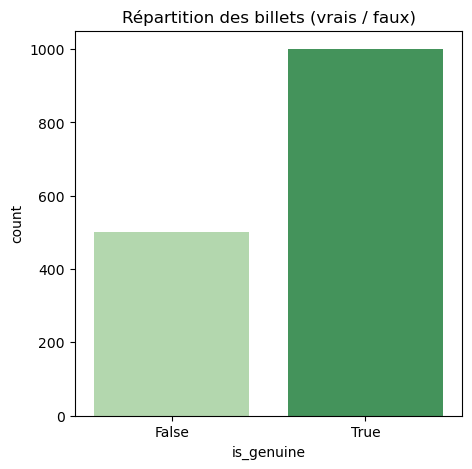

In [35]:
plt.figure(figsize=(5,5))
sns.countplot(data=df_billets, x='is_genuine', hue='is_genuine', palette="Greens", legend=False)
plt.title("Répartition des billets (vrais / faux)")
plt.show()

<Axes: >

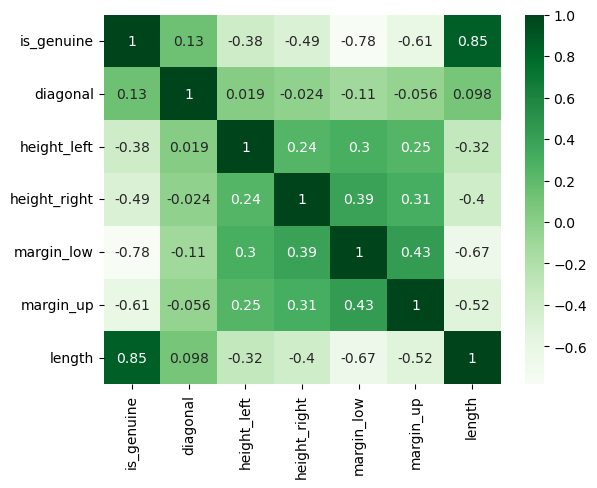

In [36]:
sns.heatmap(df_billets.corr(), annot=True, cmap='Greens')

Variables les plus corréler à is_genuine : lenght, margin_low et margin_up

Forte corrélations entre les dimensions : length avec margin_low et margin_up → forte corrélation négative

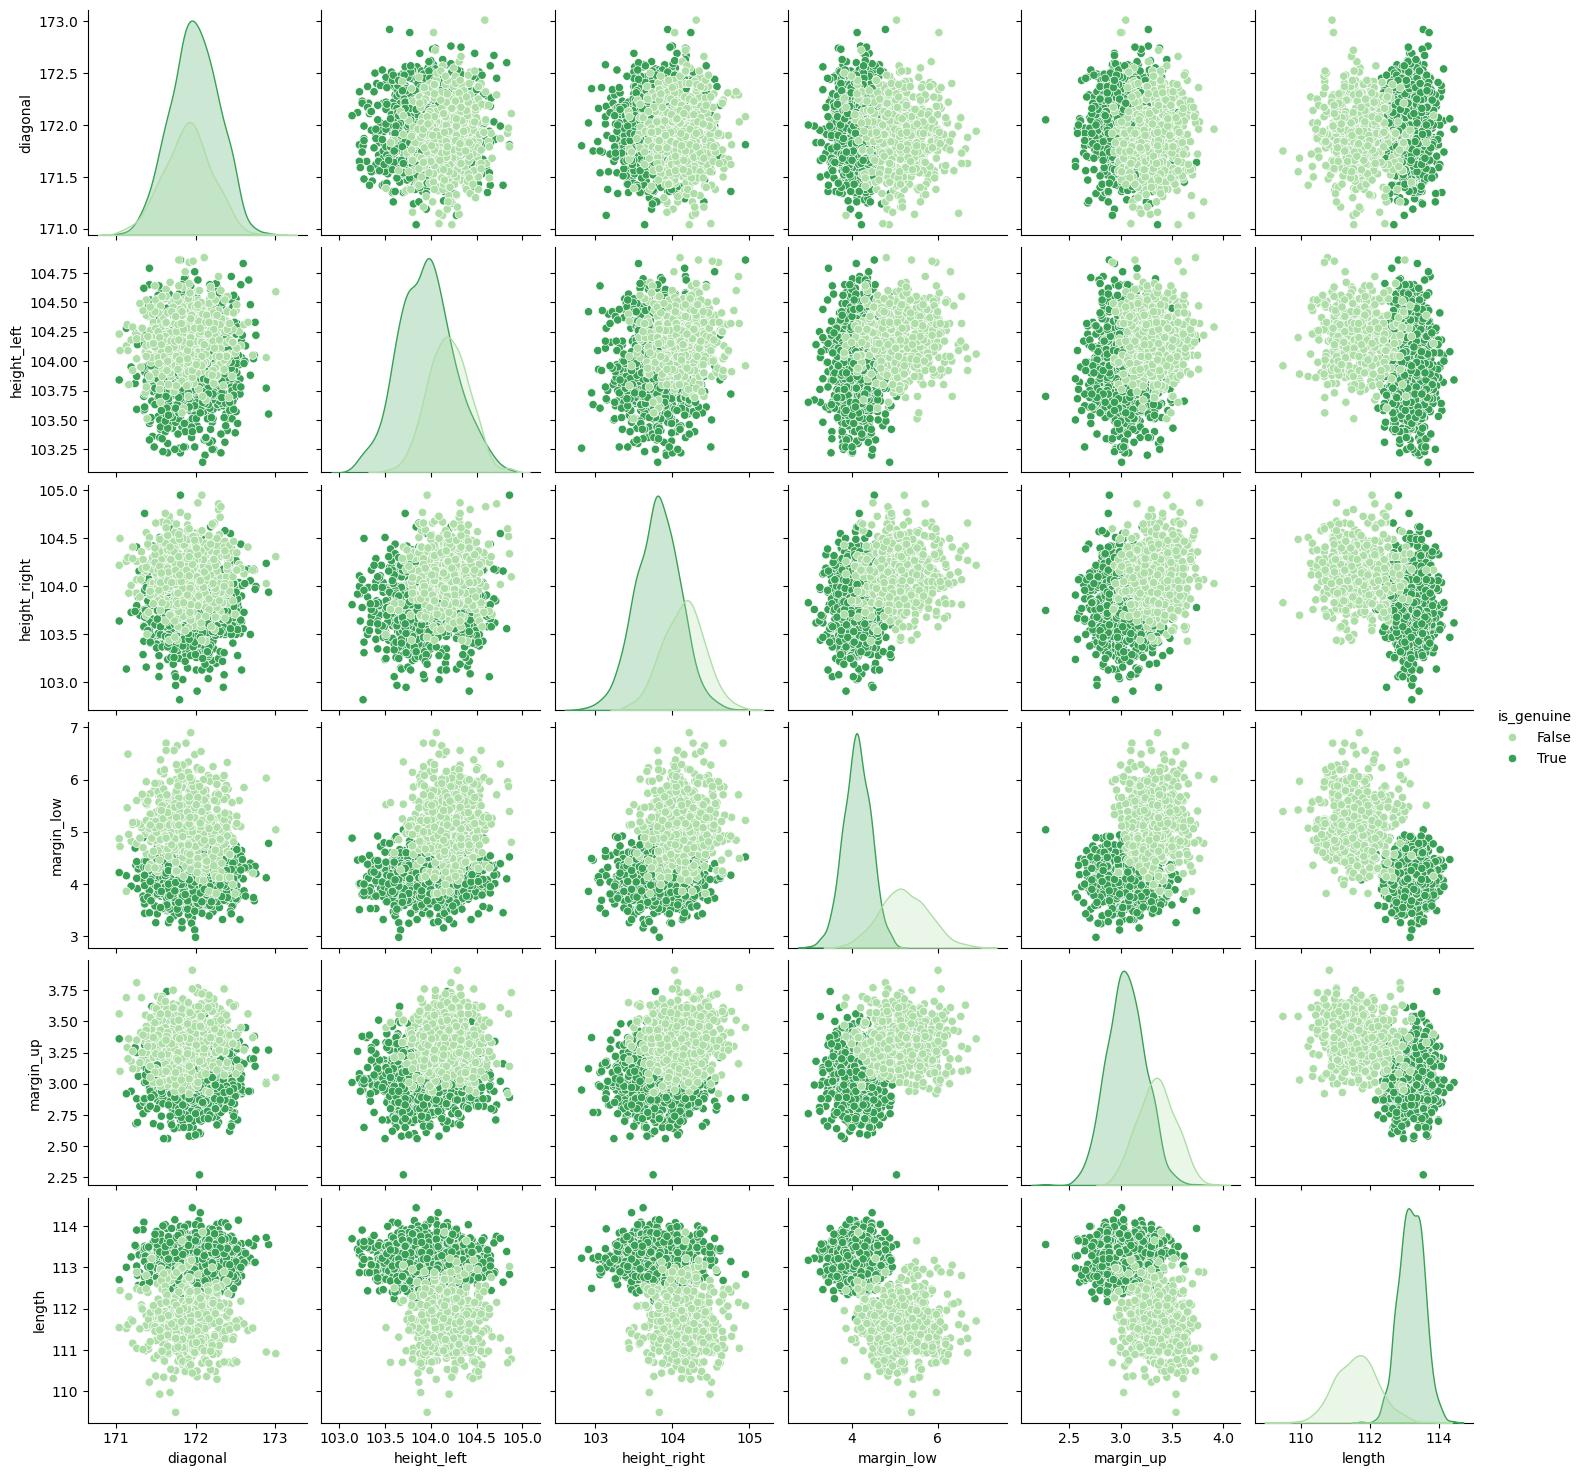

In [37]:
variables = ['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length', 'is_genuine']
sns.pairplot(df_billets[variables],hue='is_genuine',palette='Greens',diag_kind='kde')

Séparation nette entre les classes pour : 
- length
- margin_low
- margin_up

On peut distinguer que les vrais billets ont plus de longueur et des marges plus petites alors que les faux billets ont une plus courte longueur et des marges plus larges.

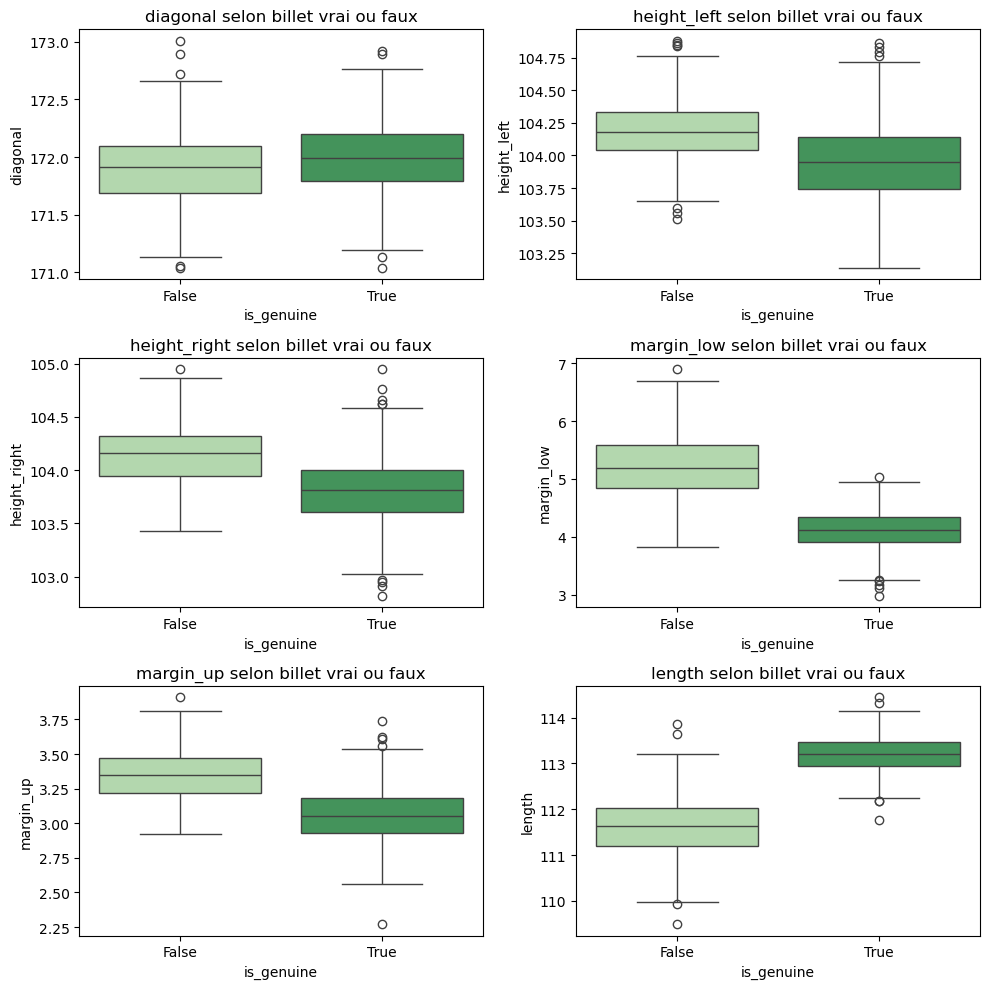

In [38]:
variables = ['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']

plt.figure(figsize=(10, 10))

for i, var in enumerate(variables, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(data=df_billets, x='is_genuine', y=var, hue='is_genuine', palette="Greens", legend=False)
    plt.title(f"{var} selon billet vrai ou faux")
    plt.xlabel("is_genuine")
    plt.ylabel(var)

plt.tight_layout()
plt.show()

length :
- Vrais billets (True) : plus longs
- Faux billets (False) : plus courts
→ Très bon discriminant

margin_low et margin_up :
- Vrais billets (True) : marge plus courtes
- Faux billets (False) : marge plus grandes
→ Très bon discriminant

height_left et height_right : légère différence → moins utile pour séparer fortement les classes, mais exploitable

diagonal : différence faible mais existante → moins utile pour séparer fortement les classes, mais exploitable

<div style="background-color: #E0EDC6; border-radius: 12px;" >
<h3 style="margin: auto; padding: 20px; color:#000000; ">1.3 - Traitement des valeurs manquantes</h3>
</div>

Il nous manque 37 valeurs dans la colonne margin_low, il nous faut traiter ces valeurs avant de mettre en place l'algorithme de détection. Plusieurs méthodes existent pour traiter les valeurs manquantes : 
- imputer ces valeurs par la médiane,
- supprimer les 37 lignes,
- régression linéaire.

Les variables sont géométriquemet liées et les écarts-types des dimensions, des billets, sont très faibles. On peut donc utiliser la régression linéaire, cela va nous établir des valeurs réaliste sans créer d'incohérences. 
On va partir directement sur une régression linéaire multiple et avec notre matrice de corrélation on va prendre toutes les variables sauf diagonal qui n'a que très peu de corrélation avec margin_low. 

In [39]:
df_billets["was_imputed"] = df_billets["margin_low"].isna()

In [40]:
#Séparation des lignes
df_complete = df_billets[df_billets['margin_low'].notnull()]
df_missing = df_billets[df_billets['margin_low'].isnull()]

In [41]:
#Variables explicatives
x_1 = df_complete[['height_left', 'height_right', 'margin_up', 'length']].copy()
y_1 = df_complete['margin_low'].copy()

#Régression linéaire
model = LinearRegression()
model.fit(x_1, y_1)
Coeff = pd.DataFrame({'variable': x_1.columns,'coefficient': model.coef_})
R2 = model.score(x_1,y_1)
print("Coefficients du modèle :")
print(Coeff)
print("\nR² du modèle :", R2)

Coefficients du modèle :
       variable  coefficient
0   height_left     0.177947
1  height_right     0.254996
2     margin_up     0.258798
3        length    -0.413644

R² du modèle : 0.4747600714833765


Le modèle explique environ 47,5% de la variance de margin_low, ce n'est pas très précis. Etant donné que nous avons deux populations différentes (vrai ou faux), les relations géométrique peuvent être un peu non linéaire. c'est à dire que les dimensions se ressemblent plus entre eux qu'à la moyenne globale.

On refait la régression linéaire mais cette fois-ci, on inclu la variable is_genuine, qui indique si le billet est vrai ou non. L'utilisation de is_genuine intervient avant toute phase de modélisation prédictive et l'imputation est appliquée uniquement sur des billets dont l'état (vrai ou faux) est connu au moment de la collecte.

In [42]:
#Variables explicatives
X_2 = df_complete[['is_genuine', 'height_left', 'height_right', 'margin_up', 'length']].copy()
y_2 = df_complete['margin_low'].copy()

#Régression linéaire
model = LinearRegression()
model.fit(X_2, y_2)

LinearRegression()

In [43]:
# Conversion de is_genuine en numérique (0 / 1)
X_2['is_genuine'] = X_2['is_genuine'].astype(int)

# Ajout d'une constante (obligatoire pour statsmodels)
X_const = sm.add_constant(X_2)

# Modèle OLS (Ordinary Least Squares)
model = sm.OLS(y_2, X_const).fit()

#Résumé complet
print(model.summary())

#Tableau p-values :
results = pd.DataFrame({
    "Variable": model.params.index,
    "Coefficient": model.params.values,
    "p-value": model.pvalues.values})

print("\nP-values des coefficients :")
print(results)

                            OLS Regression Results                            
Dep. Variable:             margin_low   R-squared:                       0.617
Model:                            OLS   Adj. R-squared:                  0.616
Method:                 Least Squares   F-statistic:                     469.1
Date:                Tue, 16 Dec 2025   Prob (F-statistic):          2.23e-300
Time:                        12:49:39   Log-Likelihood:                -774.20
No. Observations:                1463   AIC:                             1560.
Df Residuals:                    1457   BIC:                             1592.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.7806      6.025      0.130   

L'ajout de la variable is_genuine permet une imputation plus cohérente. Avec cette nouvelle variable le modèle explique 61,7% de la variance de margin_low, le score est plutôt bon. 

- p-value < 0.05 → variable statistiquement significative 
- p-value > 0.05 → variable peu ou pas informative dans ce modèle

L'analyse des p-values (P>|t|) montre que les variables is_genuine et margin_up sont significatives.

On va imputer les valeurs manquantes avec cette méthode et vérifier à l'aide de graphique si les résultats sont cohérents.

In [44]:
#Convertir is_genuine en numérique pour la régression qui utiliseque des nombre
df_billets['is_genuine'] = df_billets['is_genuine'].astype(int)

#Sauvegarde des valeurs avant imputation
df_avant = df_billets.copy()

#Séparation données complètes / manquantes
df_complete = df_billets[df_billets['margin_low'].notnull()]
df_missing = df_billets[df_billets['margin_low'].isnull()]

#Variables explicatives
X_train = df_complete[['is_genuine', 'height_left', 'height_right', 'margin_up', 'length']]
y_train = df_complete['margin_low']

#Régression linéaire
model = LinearRegression()
model.fit(X_train, y_train)

#Prédiction pour les valeurs manquantes
X_missing = df_missing[['is_genuine', 'height_left', 'height_right', 'margin_up', 'length']]
predicted_values = model.predict(X_missing)

#Remplacement dans le dataframe original
df_billets.loc[df_billets['margin_low'].isnull(), 'margin_low'] = predicted_values

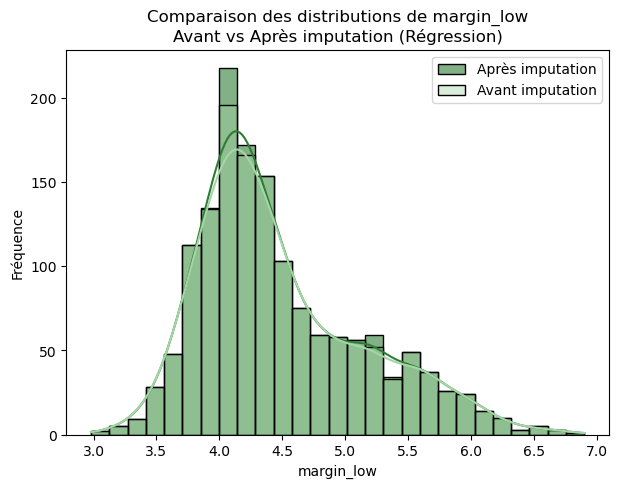

In [45]:
plt.figure(figsize=(7,5))

sns.histplot(df_billets['margin_low'], kde=True, label="Après imputation", color="#2e7d32", alpha=0.6)
sns.histplot(df_avant['margin_low'].dropna(), kde=True, label="Avant imputation", color="#a5d6a7", alpha=0.4)

plt.legend()
plt.title("Comparaison des distributions de margin_low\nAvant vs Après imputation (Régression)")
plt.xlabel("margin_low")
plt.ylabel("Fréquence")
plt.show()

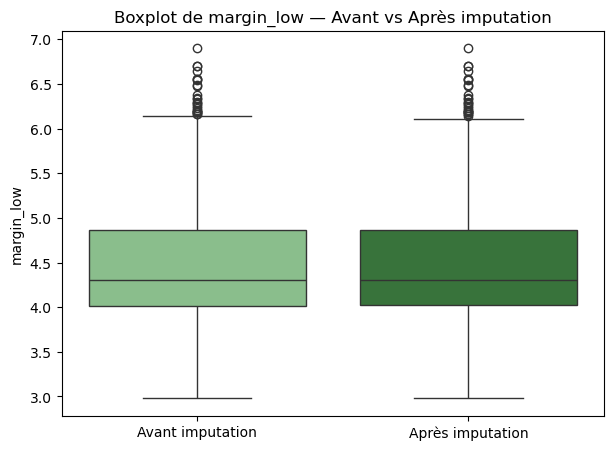

In [46]:
plt.figure(figsize=(7,5))

df_compare = pd.DataFrame({
    "Avant imputation": df_avant['margin_low'],
    "Après imputation": df_billets['margin_low']})

sns.boxplot(data=df_compare, palette=['#81c784', '#2e7d32'])
plt.title("Boxplot de margin_low — Avant vs Après imputation")
plt.ylabel("margin_low")
plt.show()

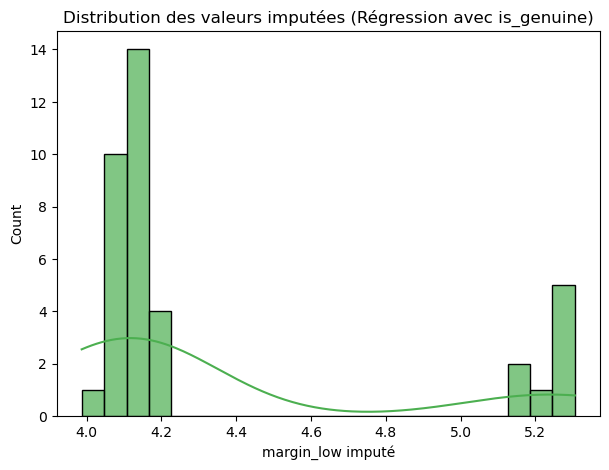

Nombre de valeurs imputées : 37


In [47]:
missing_mask = df_avant['margin_low'].isna()
imputed_values = df_billets.loc[missing_mask, 'margin_low']

plt.figure(figsize=(7,5))
sns.histplot(imputed_values, kde=True, color="#4caf50", alpha=0.7)
plt.title("Distribution des valeurs imputées (Régression avec is_genuine)")
plt.xlabel("margin_low imputé")
plt.show()

print("Nombre de valeurs imputées :", imputed_values.shape[0])

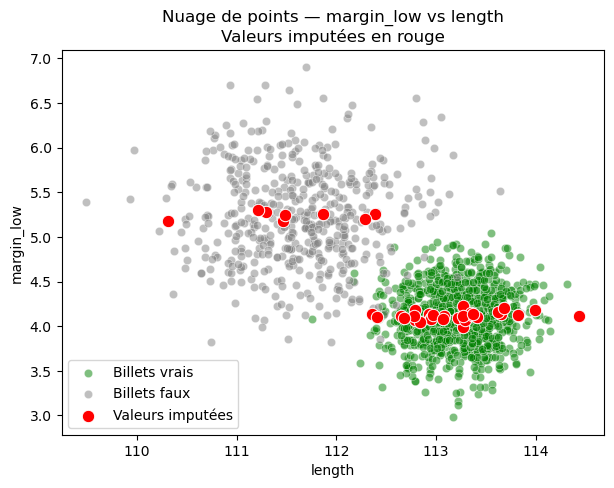

In [56]:
plt.figure(figsize=(7,5))

#Billets vrais
sns.scatterplot(data=df_billets[(df_billets["is_genuine"] == True) & (~df_billets["was_imputed"])],
    x="length",
    y="margin_low",
    color="green",
    label="Billets vrais",
    alpha=0.5)

#Billets faux
sns.scatterplot(data=df_billets[(df_billets["is_genuine"] == False) & (~df_billets["was_imputed"])],
    x="length",
    y="margin_low",
    color="grey",
    label="Billets faux",
    alpha=0.5)

#Valeurs imputées
sns.scatterplot(data=df_billets[df_billets["was_imputed"]],
    x="length",
    y="margin_low",
    color="red",
    label="Valeurs imputées",
    s=80)

plt.title("Nuage de points — margin_low vs length\nValeurs imputées en rouge")
plt.xlabel("length")
plt.ylabel("margin_low")
plt.legend()
plt.show()

- Histogramme : les courbes sont très proches → l'imputation n'a pas déformer la distribution.
- Boxplot : pas d'élargissement des valeurs extrêmes → pas d'introduction de valeurs aberrantes.
- Distribution des valeurs : deux groupes distincts → le modèle a capté la différence entre vrai et faux billets.

<div style="background-color: #85BB65; border-radius: 12px;" >
<h2 style="margin: auto; padding: 20px; color:#000000; ">Etape 2 - Modélisation des l'algorithmes de détection</h2>
</div>

Lorsque l'on construit un modèle (régression logistique, KNN, random forest), il va apprendre à reconnaître les modèles géométriques qui séparent les vrais et faux billets. Pour savoir s’il fonctionne bien, on doit le tester sur des données qu’il n’a jamais vues → Sinon, le modèle serait seulement “bon” sur les données d’entraînement, mais mauvais dans la réalité.

Pour cela on peut utiliser d'un simple train/test → le modèle sera entraînésur 80% et testé une seul fois sur 20%. Les performances peuvent être faussées si par hasard le test contient des cas trop faciles ou trop difficiles.

On va donc utiliser la validation croisée (K-fold cross-validation) pour contourner ces problèmes. c'est une méthode d'évaluation d'un modèle qui consiste à ne pas tester une seule fois le modèle sur un seul jeu de test, mais à répéter plusieurs tests sur plusieurs sous-échantillons de données, puis moyenner les performances. Avec cette méthode on va obtenir : 
- une performance plus stable,
- une performance plus généralisable,
- une évaluation moins sensible au hasard,
- le modèle sera jugé sur l'ensemble des données.

In [200]:
# Sélection des variables
X = df_billets[['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']]
y = df_billets['is_genuine']

<div style="background-color: #E0EDC6; border-radius: 12px;" >
<h3 style="margin: auto; padding: 20px; color:#000000; ">2.1 - Régression Logistique</h3>
</div>

La régression logistique est un algorithme supervisé de classification, destiné à prédire une probabilité d’appartenance à une classe. Elle applique une fonction sigmoïde (courbe en S) pour convertir la combinaison des variables explicatives en une probabilité comprise entre 0 et 1. Le modèle détermine ensuite un seuil (par défaut 0,5) pour classer l’observation dans la catégorie correspondante.

In [201]:
#Pipeline = scaling + modèle
pipe_log = Pipeline([
    ("scaler", StandardScaler()),
    ("log_reg", LogisticRegression(max_iter=1000))])

#Validation croisée stratifiée
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Accuracy CV (moyenne + écart-type)
scores = cross_val_score(pipe_log, X, y, cv=cv, scoring="accuracy")
print(f"Validation croisée – Accuracy : {scores.mean():.4f} (écart-type: {scores.std():.4f})")

Validation croisée – Accuracy : 0.9933 (écart-type: 0.0030)


Les coefficients de la régression logistique ont été extraits après entraînement du modèle final encapsulé dans une pipeline incluant une standardisation des variables. Cette approche garantit l’absence de fuite d’information et permet une comparaison directe de l’influence relative des variables sur la décision de classification.

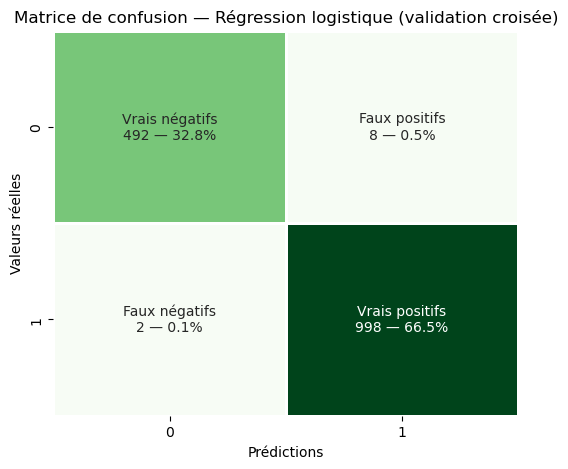

In [202]:
#Prédictions CV pour matrice de confusion
y_pred_cv = cross_val_predict(pipe_log, X, y, cv=cv)

#Matrice de confusion
cm = confusion_matrix(y, y_pred_cv)
TN, FP, FN, TP = cm.ravel()
cm_percent = cm / cm.sum()

labels = np.array([
    [f"Vrais négatifs\n{TN} — {cm_percent[0,0]*100:.1f}%",
     f"Faux positifs\n{FP} — {cm_percent[0,1]*100:.1f}%"],
    [f"Faux négatifs\n{FN} — {cm_percent[1,0]*100:.1f}%",
     f"Vrais positifs\n{TP} — {cm_percent[1,1]*100:.1f}%"]])

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=labels, fmt="", cmap="Greens", cbar=False, linewidths=1)
plt.title("Matrice de confusion — Régression logistique (validation croisée)")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.show()

In [203]:
#Rapport de classification CV
print("\nRapport de classification — Régression logistique (CV):\n")
print(classification_report(y, y_pred_cv))


Rapport de classification — Régression logistique (CV):

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       500
           1       0.99      1.00      1.00      1000

    accuracy                           0.99      1500
   macro avg       0.99      0.99      0.99      1500
weighted avg       0.99      0.99      0.99      1500



In [204]:
#Entraînement final du pipeline
pipe_log.fit(X, y)

#Récupération du modèle de régression logistique dans la pipeline
log_reg_final = pipe_log.named_steps["log_reg"]

#Tableau des coefficients
coef_df = pd.DataFrame({"Variable": X.columns,"Coefficient": log_reg_final.coef_[0]}).sort_values(by="Coefficient", ascending=False)
print("\nImportance des variables — Régression logistique :")
print(coef_df)


Importance des variables — Régression logistique :
       Variable  Coefficient
5        length     3.713067
0      diagonal     0.190926
1   height_left    -0.408372
2  height_right    -0.765401
4     margin_up    -1.726202
3    margin_low    -2.833396


- Vrais positifs : 998 → billets authentiques bien détectés
- Vrais négatifs : 492 → faux billets correctement identifiés
- Faux positifs : 8 → 8 faux billets classés comme vrais
- Faux négatifs : 2 → 2 vrais billets classés comme faux

La régression logistique avec la validation croisée obtient une accuracy globale de 99%.

La longueur et les magres du billet sont les paramètres les plus discriminants dans la décision.

<div style="background-color: #E0EDC6; border-radius: 12px;" >
<h3 style="margin: auto; padding: 20px; color:#000000; ">2.3 - KNN</h3>
</div>

L’algorithme des k plus proches voisins (KNN) est un modèle supervisé basé sur la proximité entre les observations. Pour classifier un nouvel échantillon, le modèle recherche les k observations les plus proches dans l’espace des données, puis détermine sa classe en fonction de la majorité parmi ces voisins. KNN ne construit pas de modèle interne : il stocke les données et décide au moment de la prédiction, ce qui en fait un algorithme intuitif mais sensible au choix du paramètre k et au dimensionnement des variables.

Le KNN est très sensible au choix du k, mais : 
- bas k → surapprentissage
- haut k → trop global

On va tester plusieurs valeurs de k pour voir si on peut avoir un meilleur résultat

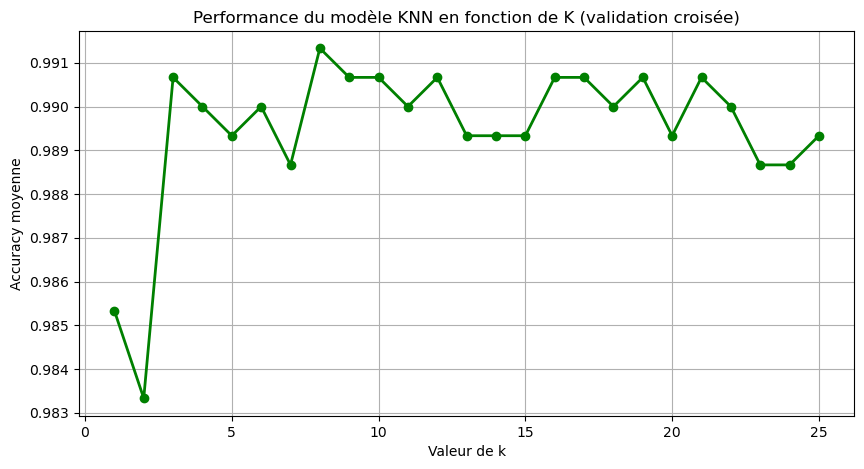

Meilleur K : 8 avec accuracy = 0.9913


In [205]:
k_values = range(1, 26)
accuracies = []

for k in k_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))])
    
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    accuracies.append(scores.mean())

#Visualisation
plt.figure(figsize=(10,5))
plt.plot(k_values, accuracies, marker='o', linewidth=2, color="green")
plt.title("Performance du modèle KNN en fonction de K (validation croisée)")
plt.xlabel("Valeur de k")
plt.ylabel("Accuracy moyenne")
plt.grid(True)
plt.show()

#Meilleur K
best_k = k_values[np.argmax(accuracies)]
print("Meilleur K :", best_k, "avec accuracy =", round(max(accuracies),4))

In [206]:
#Pipeline KNN
pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=8))])

#Validation croisée stratifiée
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Accuracy CV (moyenne + écart-type)
scores = cross_val_score(pipe_knn, X, y, cv=cv, scoring="accuracy")
print(f"Validation croisée – Accuracy KNN (k=8) : {scores.mean():.4f} (écart-type: {scores.std():.4f})")

Validation croisée – Accuracy KNN (k=8) : 0.9900 (écart-type: 0.0056)


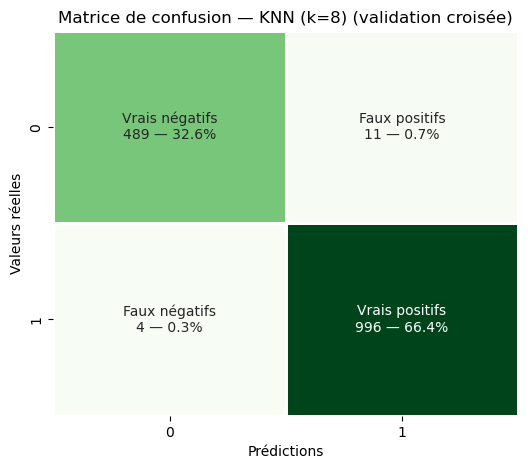

In [207]:
#Prédictions CV pour matrice de confusion
y_pred_cv = cross_val_predict(pipe_knn, X, y, cv=cv)

#Matrice de confusion
cm = confusion_matrix(y, y_pred_cv)
cm_percent = cm / cm.sum()

labels = np.array([
    [f"Vrais négatifs\n{cm[0,0]} — {cm_percent[0,0]*100:.1f}%",
     f"Faux positifs\n{cm[0,1]} — {cm_percent[0,1]*100:.1f}%"],
    [f"Faux négatifs\n{cm[1,0]} — {cm_percent[1,0]*100:.1f}%",
     f"Vrais positifs\n{cm[1,1]} — {cm_percent[1,1]*100:.1f}%"]])

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=labels, fmt="", cmap="Greens", cbar=False, linewidths=1)
plt.title("Matrice de confusion — KNN (k=8) (validation croisée)")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.show()

In [208]:
#Rapport de classification CV
print("\nRapport de classification — KNN (k=8) (CV):\n")
print(classification_report(y, y_pred_cv))


Rapport de classification — KNN (k=8) (CV):

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       500
           1       0.99      1.00      0.99      1000

    accuracy                           0.99      1500
   macro avg       0.99      0.99      0.99      1500
weighted avg       0.99      0.99      0.99      1500



- Vrais positifs : 998 → vrais billets correctement reconnus
- Vrais négatifs : 490 → faux billets correctement détectés
- Faux positifs : 10 → 10 faux billets classés comme vrais
- Faux négatifs : 2 → 2 vrais billets classés comme faux

Le KNN avec la validation croisée obtient une accuracy globale de 99%.

<div style="background-color: #E0EDC6; border-radius: 12px;" >
<h3 style="margin: auto; padding: 20px; color:#000000; ">2.4 - Random Forest</h3>
</div>

Random Forest est un algorithme supervisé de classification basé sur le principe de l’ensemble learning. Il construit un grand nombre d’arbres de décision, chacun entraîné sur un échantillon aléatoire des données et une sélection partielle des variables. Lors de la prédiction, chaque arbre fournit un vote pour une classe et le modèle retient la décision majoritaire. Cette combinaison d’arbres rend Random Forest plus robuste, réduit fortement le risque de surapprentissage et améliore la précision par rapport à un arbre seul. De plus, il offre un avantage important : il est capable de mesurer l’importance relative des variables, permettant d’identifier les caractéristiques les plus discriminantes dans la prise de décision.

In [209]:
#Modèle Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)

#Validation croisée stratifiée
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Accuracy CV (moyenne + écart-type)
scores = cross_val_score(rf, X, y, cv=cv, scoring="accuracy")
print(f"Validation croisée – Accuracy Random Forest : {scores.mean():.4f} (écart-type: {scores.std():.4f})")

Validation croisée – Accuracy Random Forest : 0.9920 (écart-type: 0.0054)


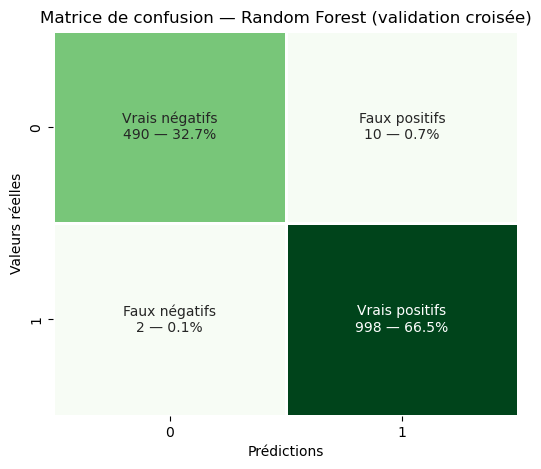

In [210]:
#Prédictions CV pour matrice de confusion
y_pred_cv = cross_val_predict(rf, X, y, cv=cv)

#Matrice de confusion
cm = confusion_matrix(y, y_pred_cv)
TN, FP, FN, TP = cm.ravel()
cm_percent = cm / cm.sum()

labels = np.array([
    [f"Vrais négatifs\n{TN} — {cm_percent[0,0]*100:.1f}%",
     f"Faux positifs\n{FP} — {cm_percent[0,1]*100:.1f}%"],
    [f"Faux négatifs\n{FN} — {cm_percent[1,0]*100:.1f}%",
     f"Vrais positifs\n{TP} — {cm_percent[1,1]*100:.1f}%"]])

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=labels, fmt="", cmap="Greens", cbar=False, linewidths=1)
plt.title("Matrice de confusion — Random Forest (validation croisée)")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.show()

In [211]:
#Rapport de classification CV
print("\nRapport de classification — Random Forest (CV):\n")
print(classification_report(y, y_pred_cv))


Rapport de classification — Random Forest (CV):

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       500
           1       0.99      1.00      0.99      1000

    accuracy                           0.99      1500
   macro avg       0.99      0.99      0.99      1500
weighted avg       0.99      0.99      0.99      1500



In [212]:
#Importance des variables 
rf.fit(X, y)

importance_df = pd.DataFrame({"Variable": X.columns, "Importance": rf.feature_importances_}).sort_values(by="Importance", ascending=False)
print("\nImportance des variables — Random Forest :")
print(importance_df)


Importance des variables — Random Forest :
       Variable  Importance
5        length    0.482534
3    margin_low    0.326666
4     margin_up    0.110378
2  height_right    0.044524
1   height_left    0.027766
0      diagonal    0.008133


- Vrais positifs : 998 → authentiques correctement identifiés
- Vrais négatifs : 490 → faux billets détectés
- Faux positifs : 10 → faux billets classés comme vrais
- Faux négatifs : 2 → vrais billets classés comme faux

Le Random Forest avec la validation croisée obtient une accuracy globale de 99%.

La longueur et les magres du billet sont les paramètres les plus discriminants dans la décision.

<div style="background-color: #E0EDC6; border-radius: 12px;" >
<h3 style="margin: auto; padding: 20px; color:#000000; ">2.2 - K-means</h3>
</div>

K-Means est un algorithme de clustering non supervisé qui vise à regrouper des observations en k groupes distincts en minimisant la distance intra-cluster. Chaque cluster est représenté par un centroïde, calculé comme la moyenne des points qui lui sont associés. L’algorithme alterne entre l’affectation des observations au centroïde le plus proche et la mise à jour des centroïdes jusqu’à convergence.

In [213]:
#Variables utilisées pour K-Means
X_cluster = df_billets[['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']]

#Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

In [214]:
inertias, silhouettes = [], []
ks = range(2, 10)

for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    preds = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, preds))

# Résumé
df_k = pd.DataFrame({"k": list(ks), "inertia": inertias, "silhouette": silhouettes})
df_k

C:\Users\Thomas G\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\Thomas G\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\Thomas G\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\Thomas G\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory le

,k,inertia,silhouette
0,2,5801.593489,0.343466
1,3,5087.631930,0.210736
2,4,4672.317099,0.196470
3,5,4355.994680,0.156737
4,6,4103.514167,0.151036
5,7,3915.791256,0.146829
6,8,3737.292811,0.145347
7,9,3595.401492,0.141220


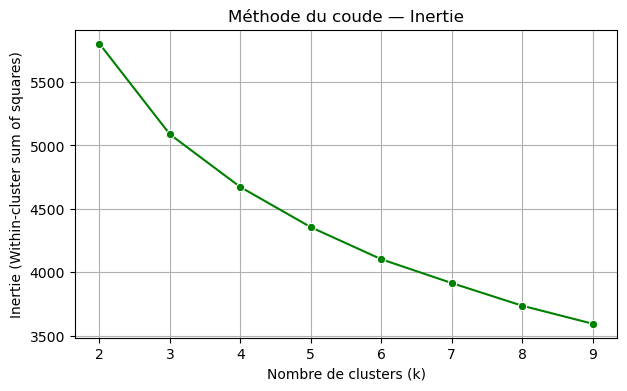

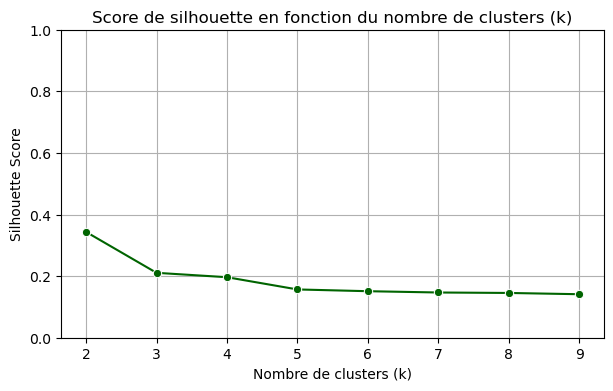

In [215]:
plt.figure(figsize=(7,4))
sns.lineplot(data=df_k, x="k", y="inertia", marker="o", color="green")
plt.title("Méthode du coude — Inertie")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie (Within-cluster sum of squares)")
plt.grid(True)
plt.show()

plt.figure(figsize=(7,4))
sns.lineplot(data=df_k, x="k", y="silhouette", marker="o", color="darkgreen")
plt.title("Score de silhouette en fonction du nombre de clusters (k)")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.ylim(0, 1)
plt.show()

Méthode du coude : On cherche un “angle” où la baisse de l’inertie devient moins forte.
→ Ici, la plus grosse chute est entre k = 2 et k = 3, puis la pente devient plus douce.

Score de silhouette : Plus le score est proche de 1, plus les clusters sont bien séparés.
→ Le score silhouette maximal est à k = 2 (≈ 0.34) puis chute fortement.

Comme on cherche un modèle prédicitif vrai/faux, on peut directement mettre k=2.

C:\Users\Thomas G\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


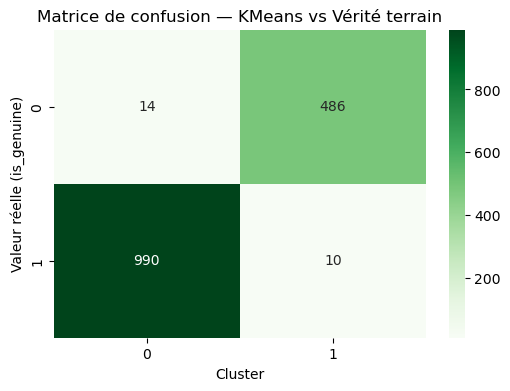

In [216]:
#k=2 selon les méthodes ci-dessus
kmeans_final = KMeans(n_clusters=2, random_state=42)
clusters = kmeans_final.fit_predict(X_scaled)

#Ajouter les clusters au dataset
df_billets["cluster"] = clusters

cm = confusion_matrix(df_billets["is_genuine"], df_billets["cluster"])

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Greens")
plt.title("Matrice de confusion — KMeans vs Vérité terrain")
plt.xlabel("Cluster")
plt.ylabel("Valeur réelle (is_genuine)")
plt.show()

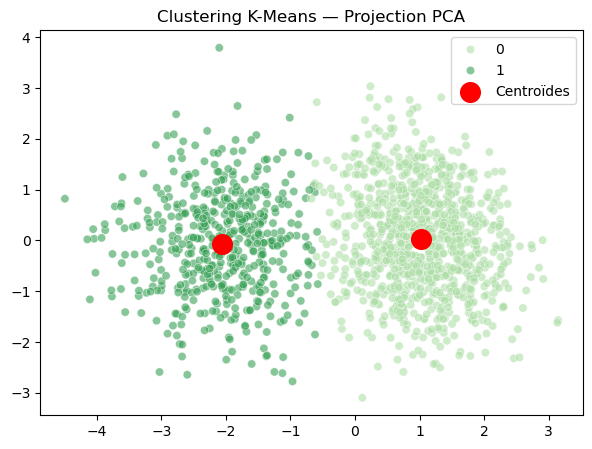

In [217]:
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

centers = kmeans_final.cluster_centers_
centers_2d = pca.transform(centers)

plt.figure(figsize=(7,5))
sns.scatterplot(
    x=components[:,0], y=components[:,1],
    hue=df_billets["cluster"],
    palette="Greens",
    alpha=0.6)

plt.scatter(centers_2d[:,0], centers_2d[:,1], s=200, c='red', label='Centroïdes')
plt.title("Clustering K-Means — Projection PCA")
plt.legend()
plt.show()

Cluster 0 correspond majoritairement aux billets vrais
- 990 vrais billets correctement regroupés
- seulement 14 faux billets mal classés

Cluster 1 correspond majoritairement aux billets faux
- 486 faux billets correctement regroupés
- seulement 10 vrais billets mal classés

K-Means n’est pas optimisé pour minimiser les erreurs de classification, mais pour minimiser la variance intra-cluster

<div style="background-color: #85BB65; border-radius: 12px;" >
<h2 style="margin: auto; padding: 20px; color:#000000; ">Etape 3 - Conclusion et choix de l'algorithme</h2>
</div>

Plusieurs méthodes de détection des faux billets ont été comparées après un traitement des données et une validation croisée stratifiée. Les modèles supervisés (régression logistique, KNN et Random Forest) obtiennent tous d’excellentes performances, avec une accuracy supérieure à 99 %.

Régression logistique → Au regard des résultats obtenus, c'est un excellent compromis entre performance, stabilité et interprétabilité, ce qui en fait le modèle le plus adapté pour une mise en production.

Les modèles KNN et Random Forest constituent de solides alternatives, tandis que le K-Means apporte un éclairage intéressant sur la structure des données, sans être adapté comme solution finale de détection.

In [218]:
#Dataset final 
X = df_billets[['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']]
y = df_billets['is_genuine']

#Pipeline complète : scaling -> modèle
pipe_final = Pipeline([
    ("scaler", StandardScaler()),
    ("log_reg", LogisticRegression(max_iter=1000))])

pipe_final.fit(X, y)
print("Pipeline entraînée")

Pipeline entraînée


In [219]:
#Sauvegarde
joblib.dump(pipe_final, "pipeline_billets_logreg.joblib")
print("Sauvegarde : pipeline_billets_logreg.joblib")

Sauvegarde : pipeline_billets_logreg.joblib
